In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scienceplots

vars_ = ["FE","NAE","NAW","NE","SAE","SAW","SE"]

df = pd.read_csv("../weekly_chile_data.csv", parse_dates=["FECHA"])
df = df.sort_values("FECHA").set_index("FECHA")

# Optional: consistent, slightly cleaner defaults for paper figures
plt.rcParams.update({
    "figure.dpi": 140,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

plt.style.use(
['science','ieee']
)

In [10]:
len(df.columns)

80

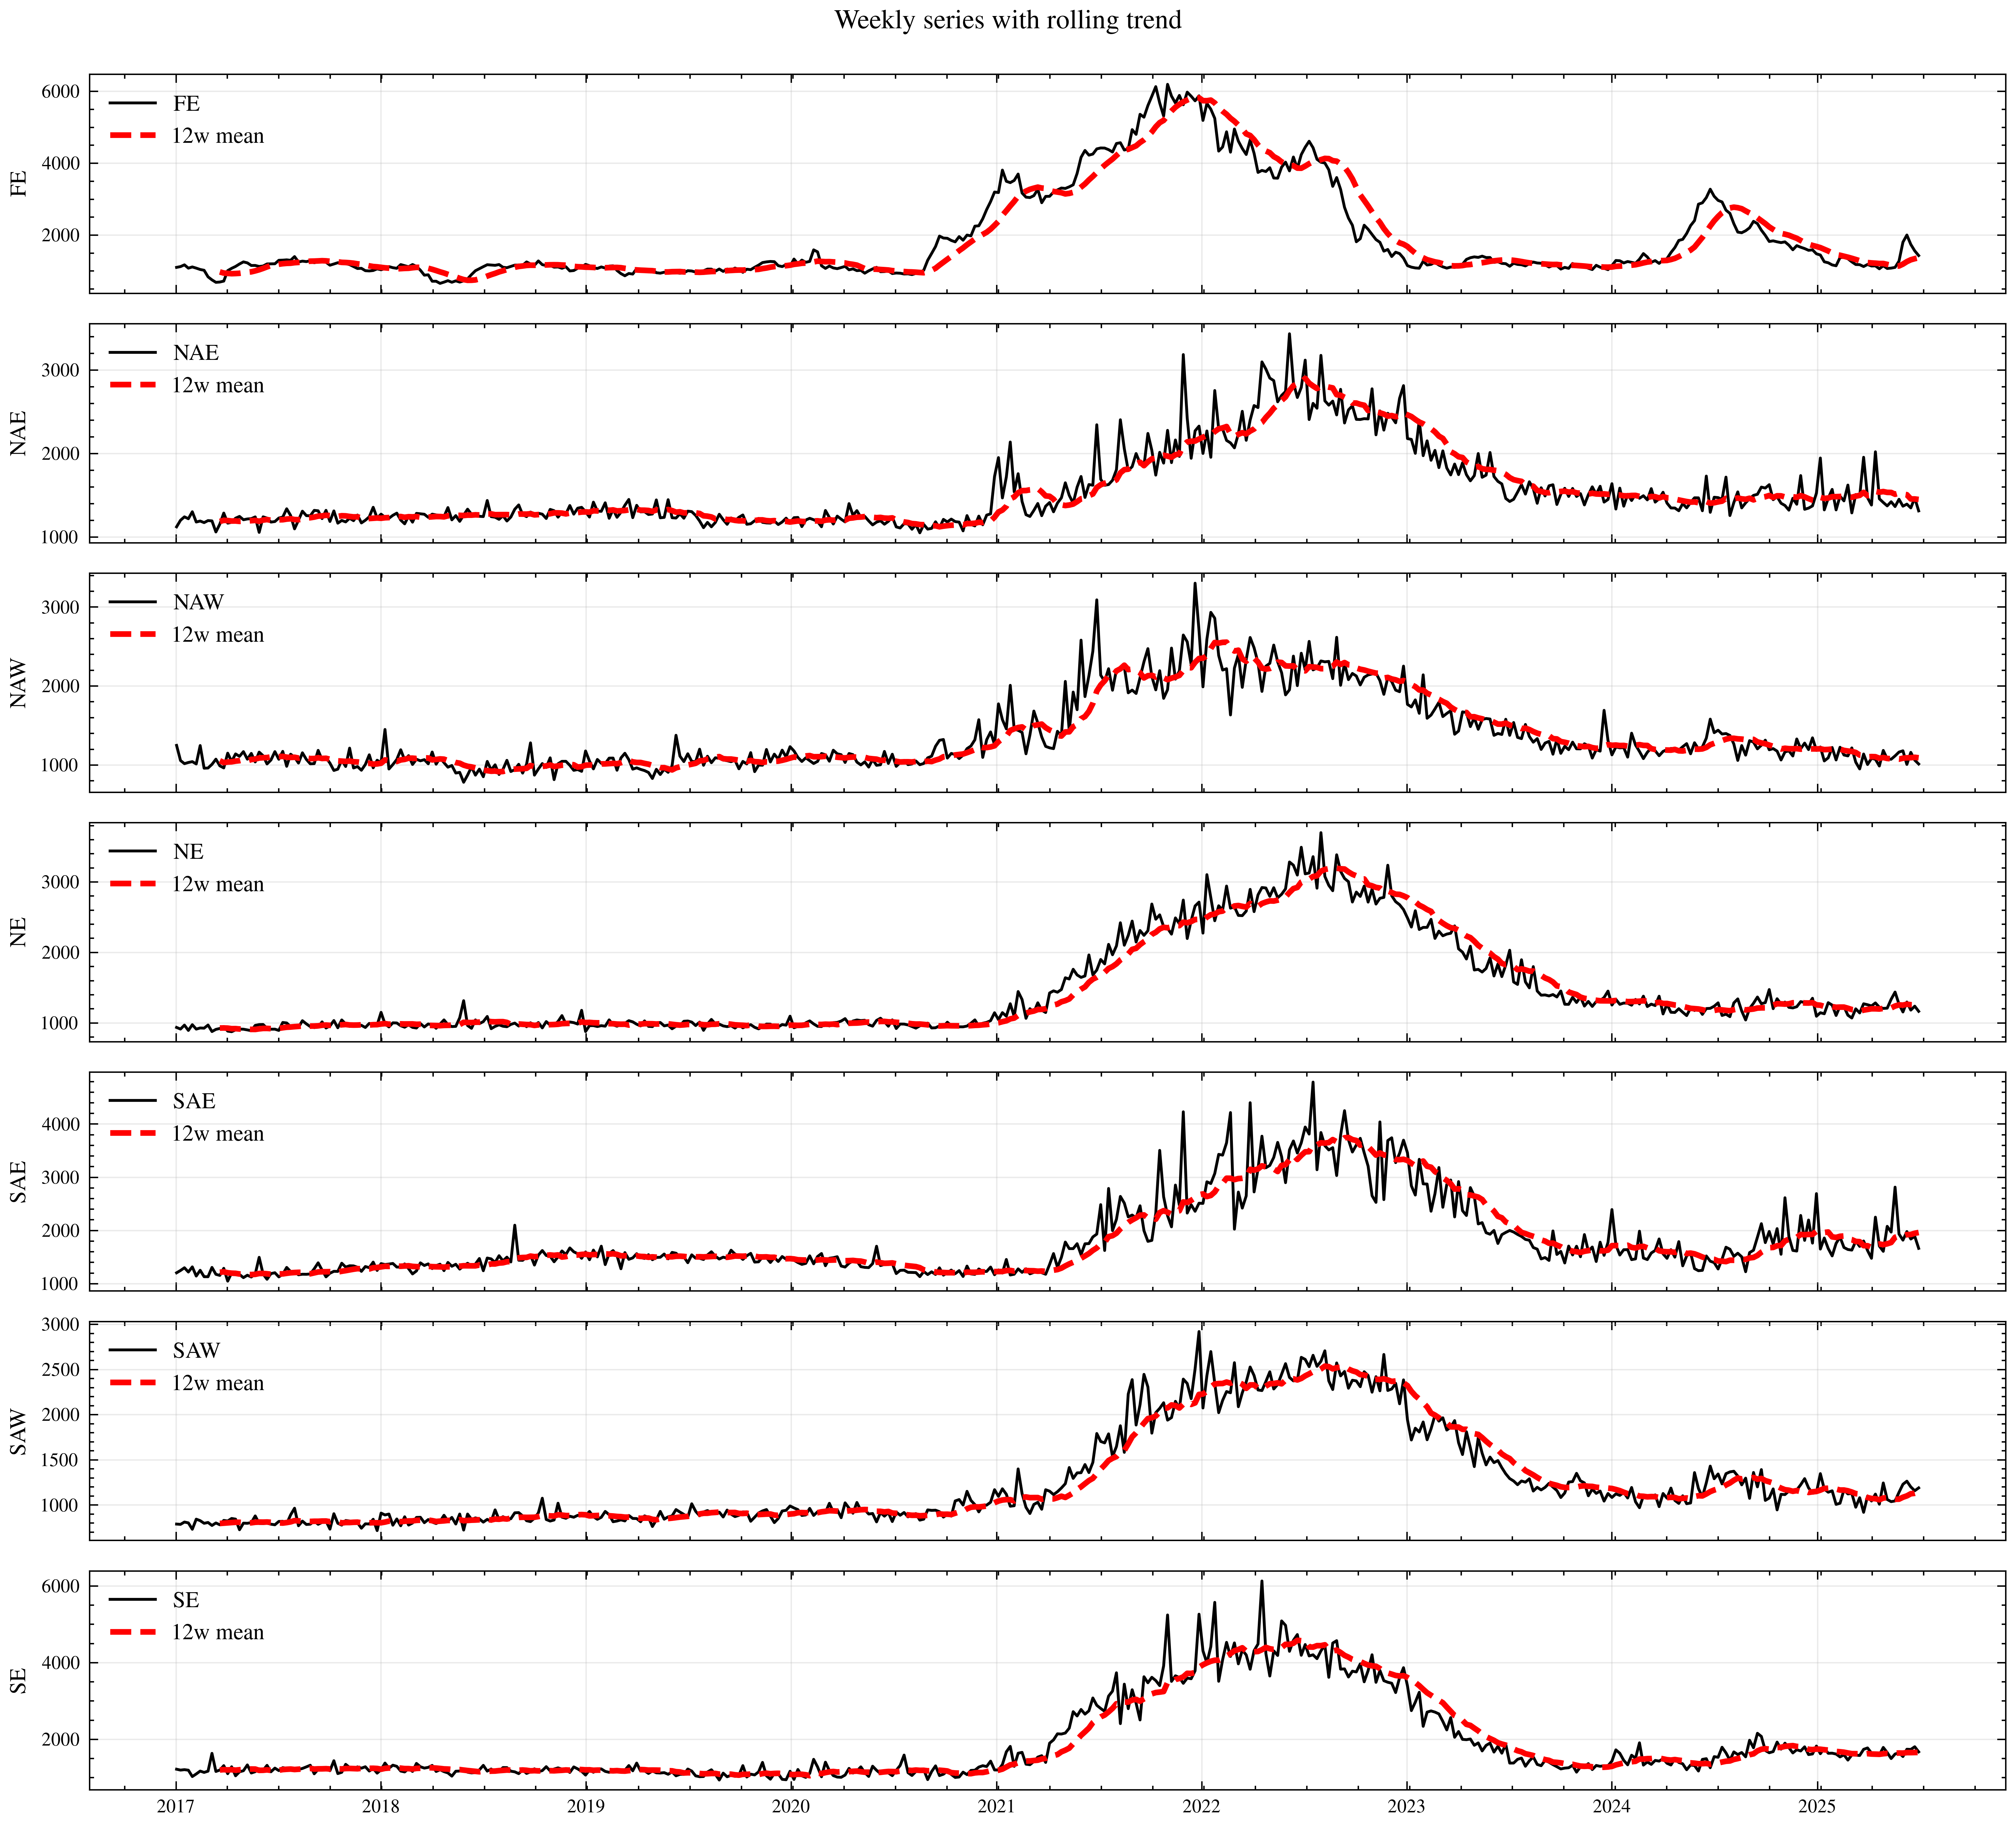

In [6]:
window = 12  # ~quarter for weekly data
fig, axes = plt.subplots(len(vars_), 1, sharex=True, figsize=(10, 9))

for ax, v in zip(axes, vars_):
    ax.plot(df.index, df[v], linewidth=1, label=v)
    ax.plot(df.index, df[v].rolling(window).mean(), linewidth=2, label=f"{window}w mean")
    ax.set_ylabel(v)
    ax.legend(loc="upper left", fontsize=8, frameon=False)

axes[-1].xaxis.set_major_locator(mdates.YearLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("Weekly series with rolling trend", y=0.995)
fig.tight_layout()

plt.savefig("../plots/weekly_series_with_trend.png", dpi=300)
plt.savefig("../plots/weekly_series_with_trend.pdf")
plt.show()

/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_36105/4213256601.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(ncol=4, fontsize=8, frameon=False)


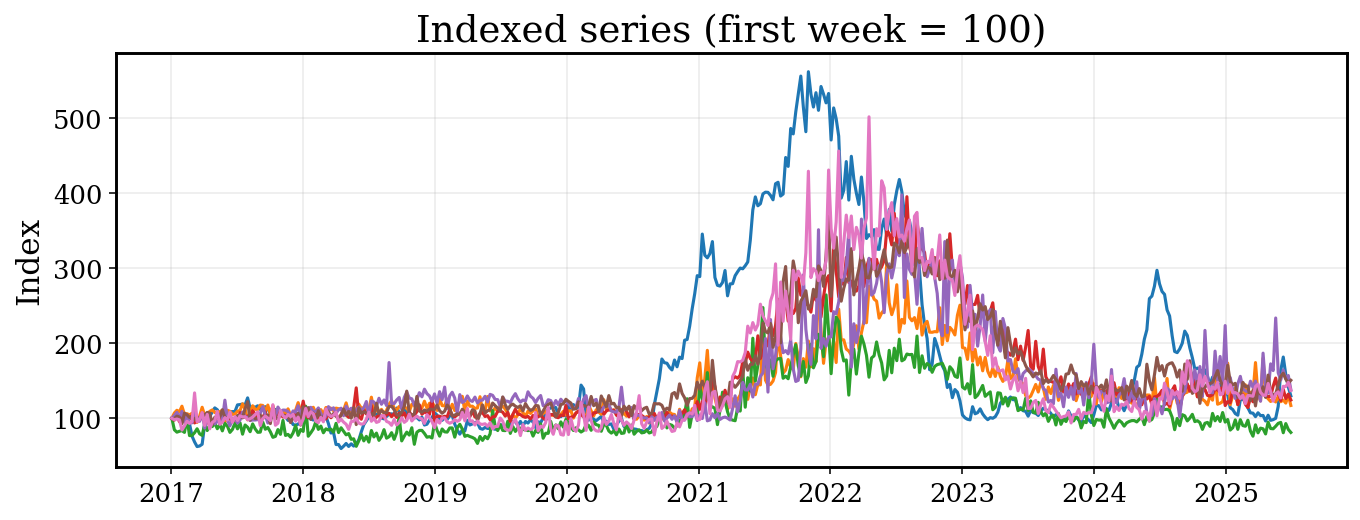

In [4]:
base = df[vars_].iloc[0]
indexed = df[vars_].div(base).mul(100)

plt.figure(figsize=(10, 4))
plt.plot(indexed.index, indexed[vars_], linewidth=1.6)
plt.title("Indexed series (first week = 100)")
plt.ylabel("Index")
plt.legend(ncol=4, fontsize=8, frameon=False)
plt.tight_layout()
plt.show()


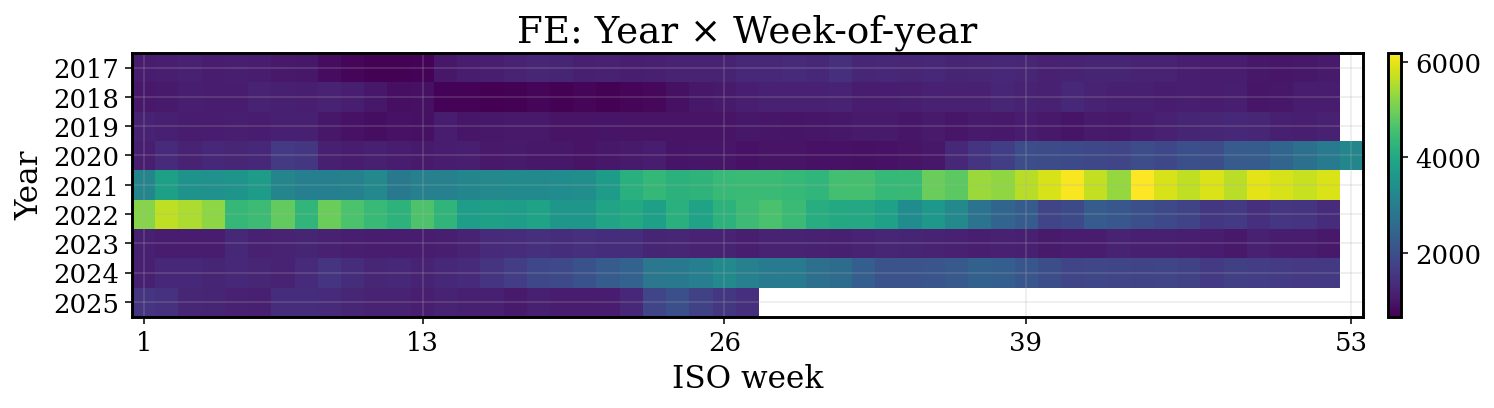

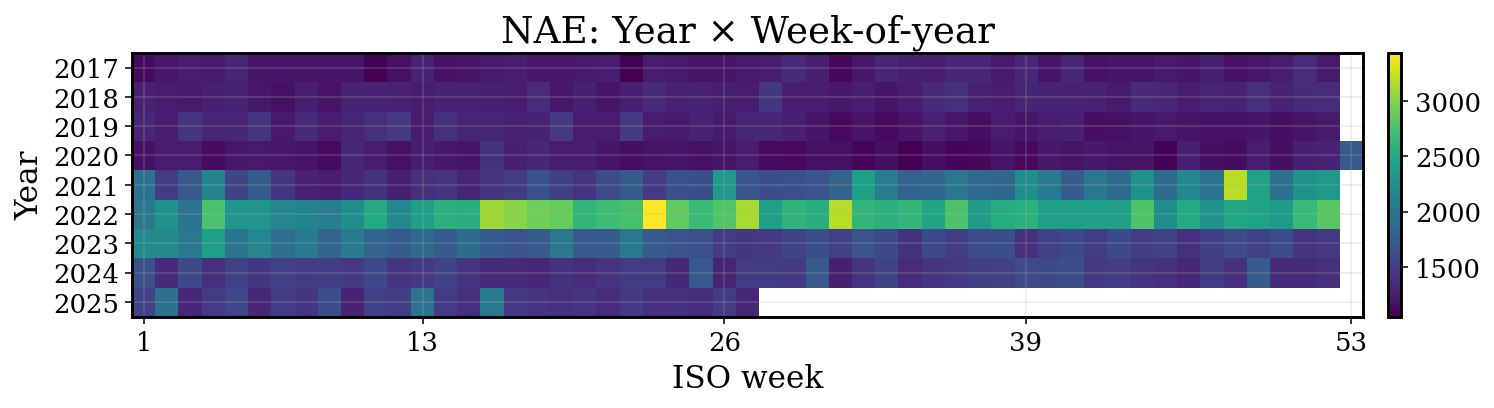

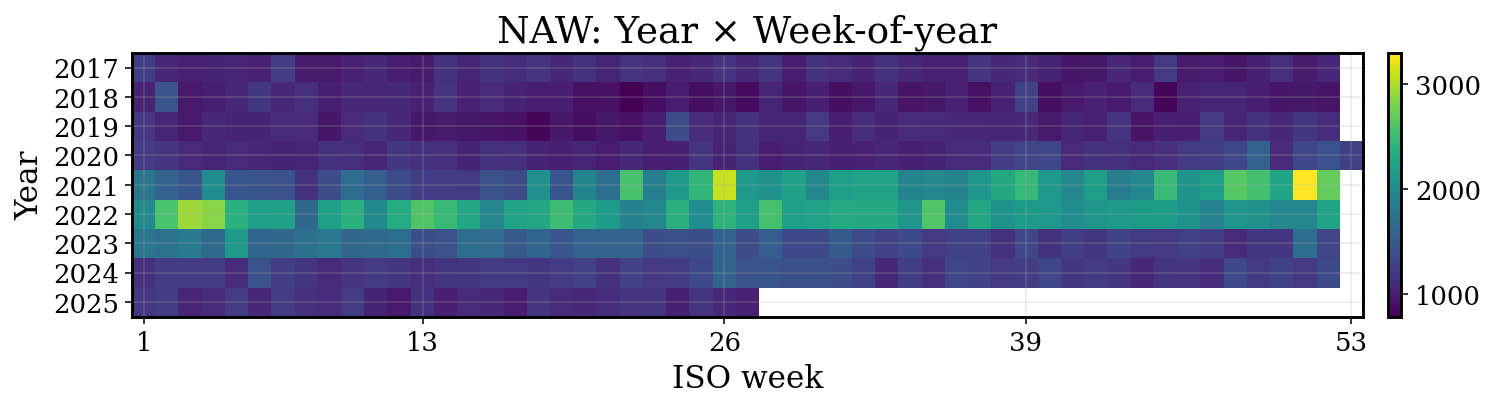

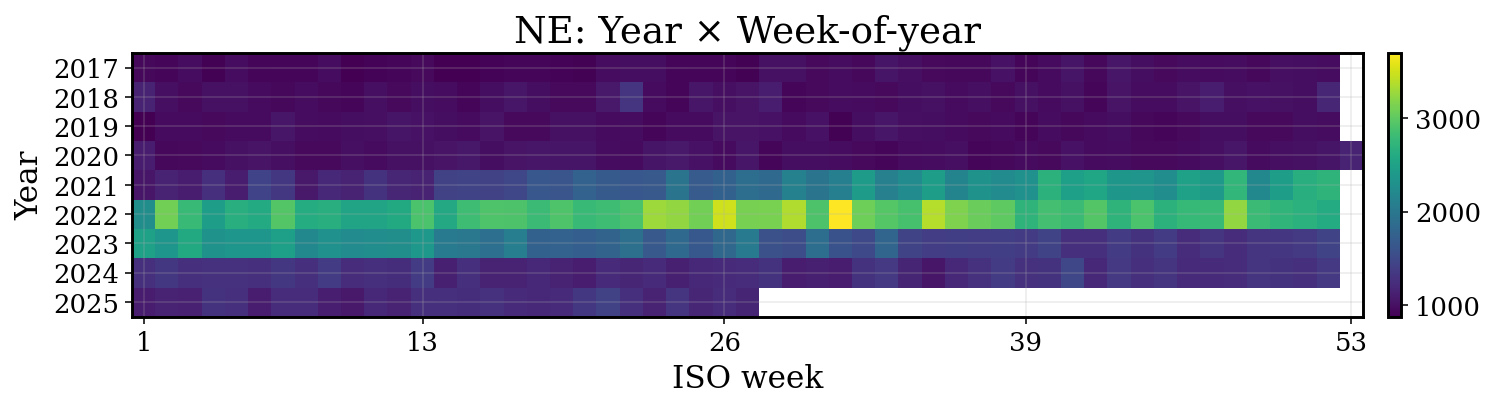

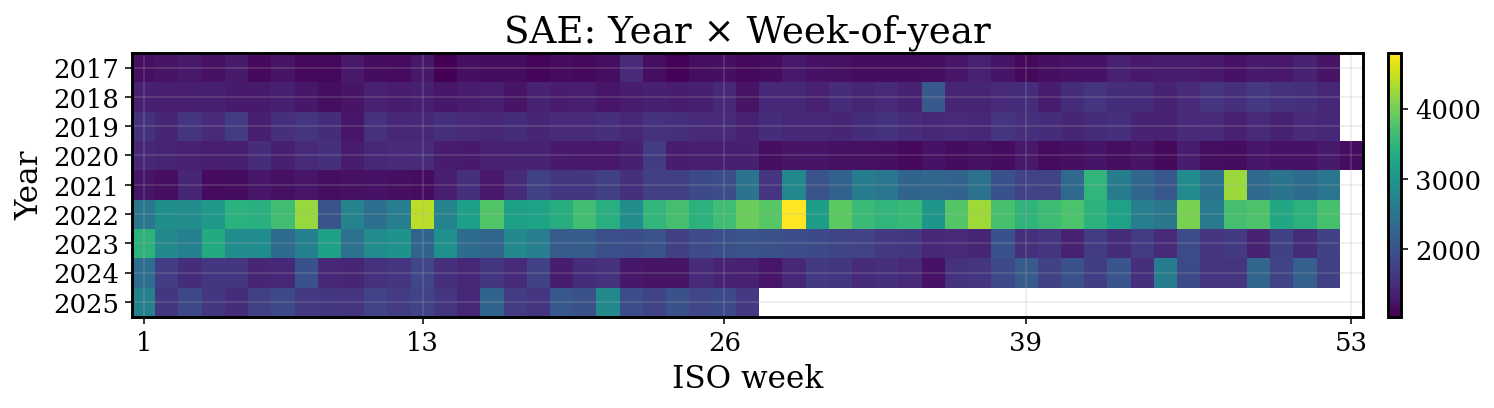

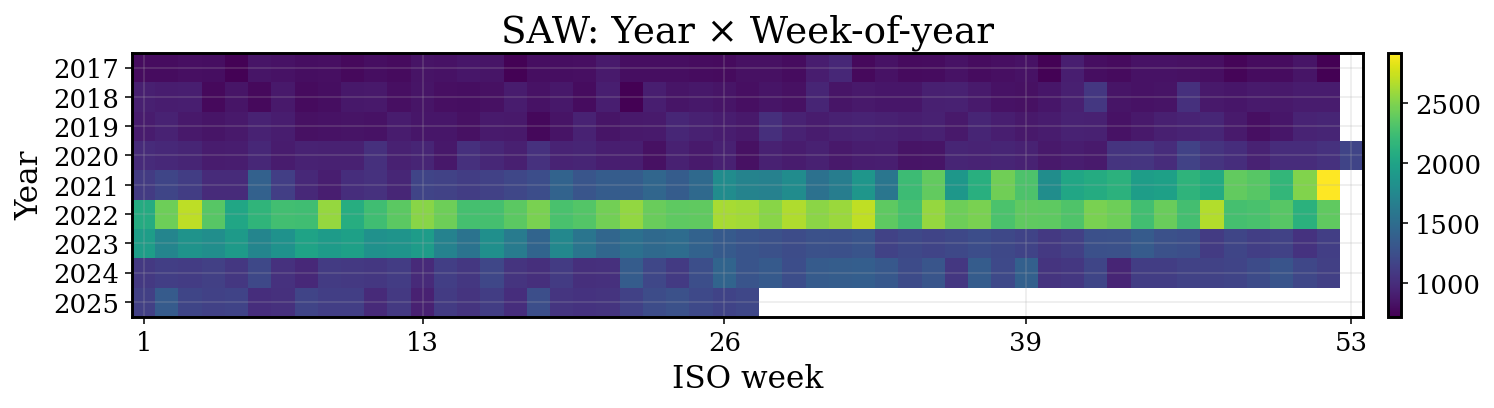

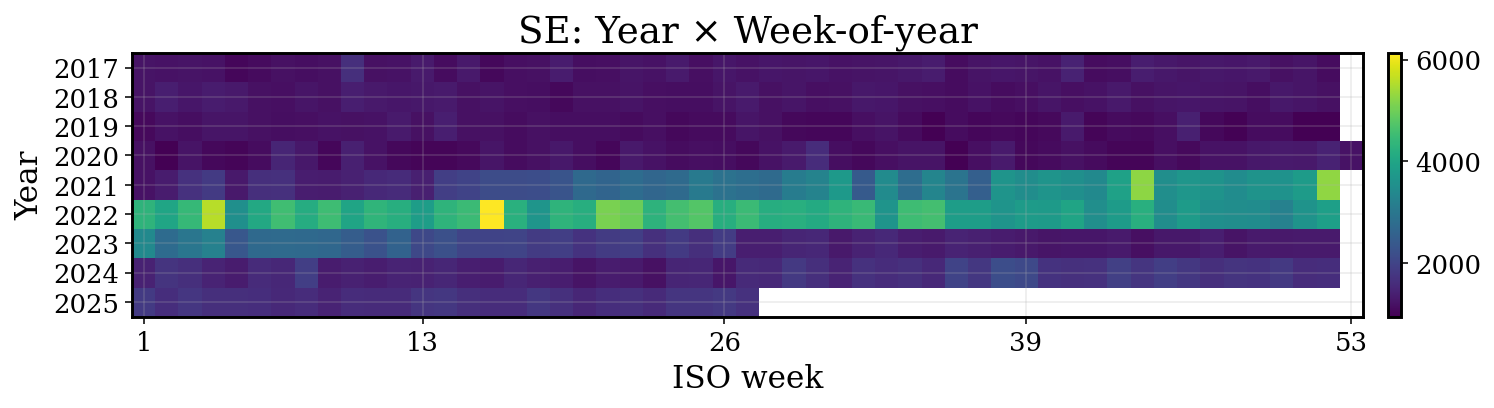

In [5]:
def seasonal_heatmap(df, col):
    tmp = df[[col]].copy()
    iso = tmp.index.isocalendar()
    tmp["year"] = iso.year.astype(int)
    tmp["week"] = iso.week.astype(int)

    pivot = tmp.pivot_table(index="year", columns="week", values=col, aggfunc="mean")
    pivot = pivot.reindex(columns=range(1, 54))  # weeks 1..53

    fig, ax = plt.subplots(figsize=(11, 3.2))
    im = ax.imshow(pivot.values, aspect="auto")
    ax.set_title(f"{col}: Year × Week-of-year")
    ax.set_xlabel("ISO week")
    ax.set_ylabel("Year")
    ax.set_xticks([0, 12, 25, 38, 52])
    ax.set_xticklabels([1, 13, 26, 39, 53])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
    plt.tight_layout()
    plt.show()

for v in vars_:
    seasonal_heatmap(df, v)


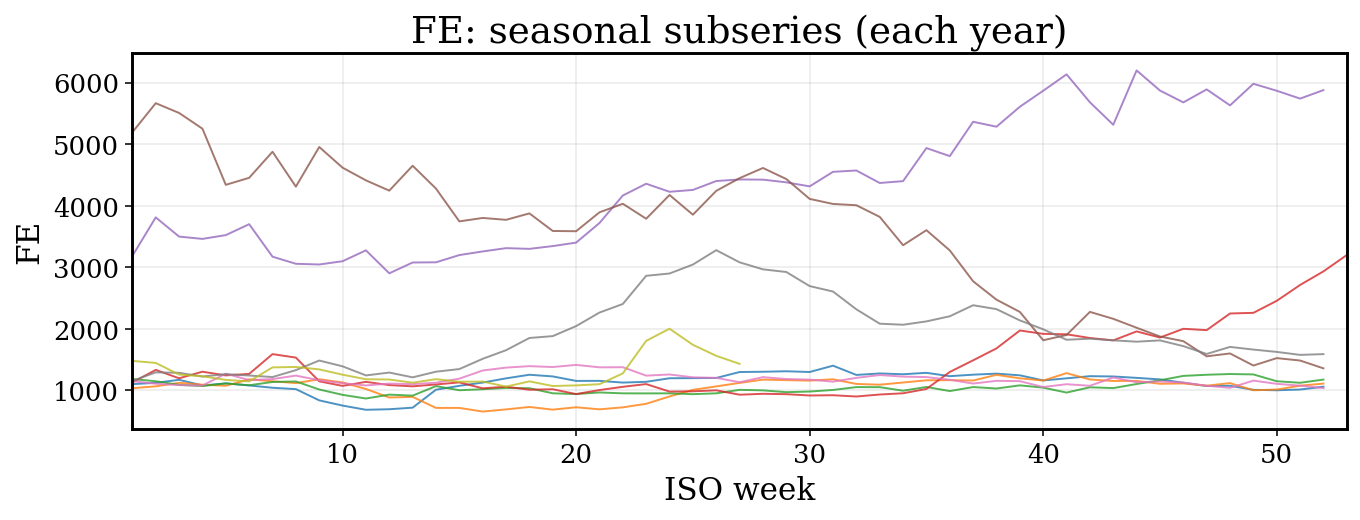

In [6]:
def seasonal_subseries(df, col):
    tmp = df[[col]].copy()
    iso = tmp.index.isocalendar()
    tmp["year"] = iso.year.astype(int)
    tmp["week"] = iso.week.astype(int)

    fig, ax = plt.subplots(figsize=(10, 4))
    for y, g in tmp.groupby("year"):
        g = g.sort_values("week")
        ax.plot(g["week"], g[col], linewidth=1, alpha=0.8)

    ax.set_title(f"{col}: seasonal subseries (each year)")
    ax.set_xlabel("ISO week")
    ax.set_ylabel(col)
    ax.set_xlim(1, 53)
    plt.tight_layout()
    plt.show()

seasonal_subseries(df, "FE")


/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_65585/1432418603.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=vars_, showfliers=True)


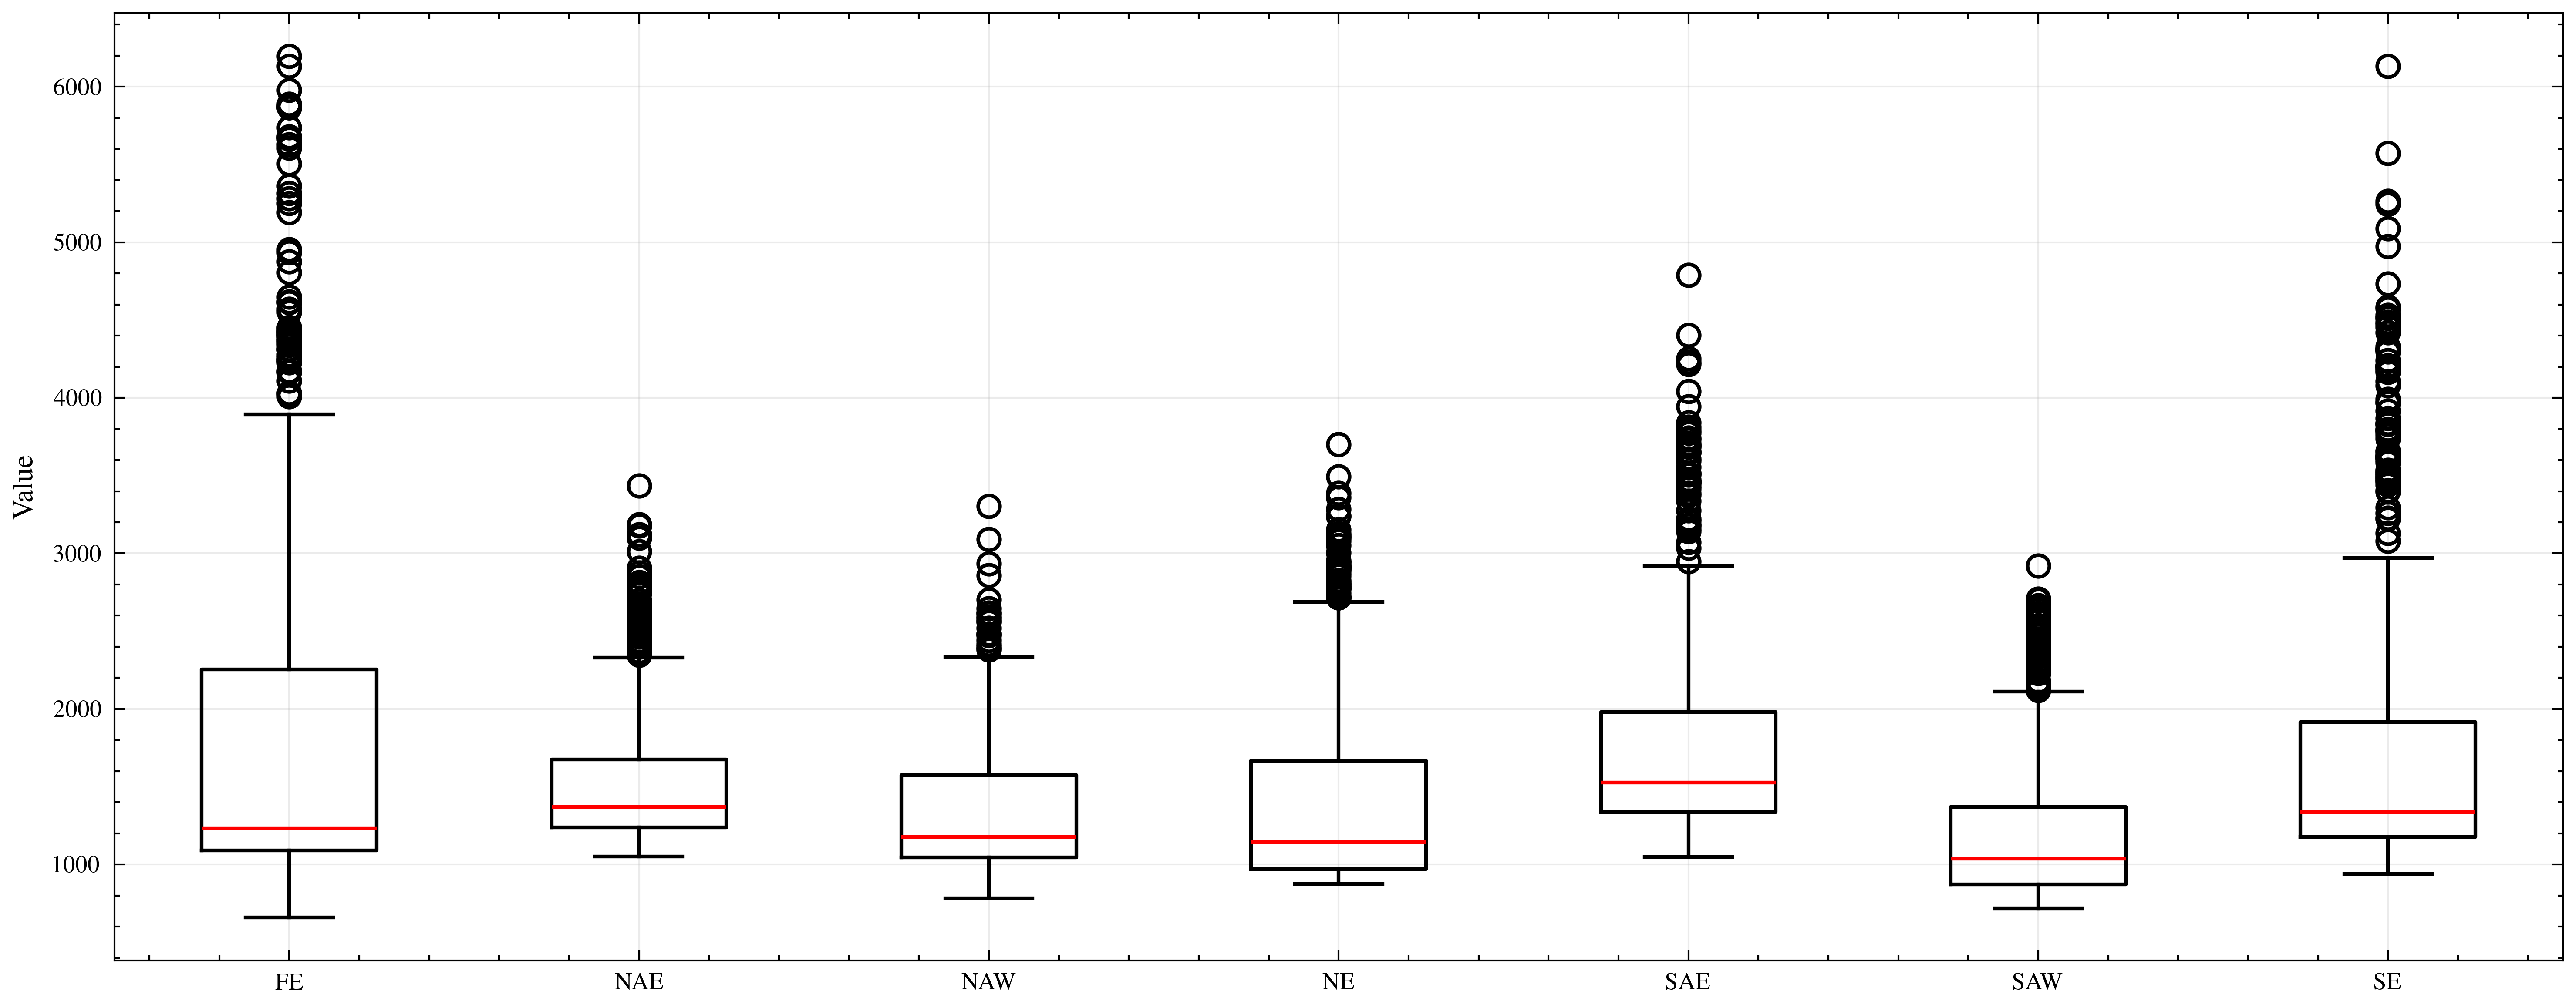

In [8]:
data = [df[v].dropna().values for v in vars_]

plt.figure(figsize=(10, 4))
plt.boxplot(data, labels=vars_, showfliers=True)
plt.ylabel("Value")
plt.tight_layout()
plt.savefig("../plots/boxplot_comparison.png", dpi=300)
plt.savefig("../plots/boxplot_comparison.pdf")
plt.show()


/var/folders/dy/8nkgqf653sggg31kzy33mjdr0000gn/T/ipykernel_36105/4275969235.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([diffs[v].values for v in vars_], labels=vars_, showfliers=True)


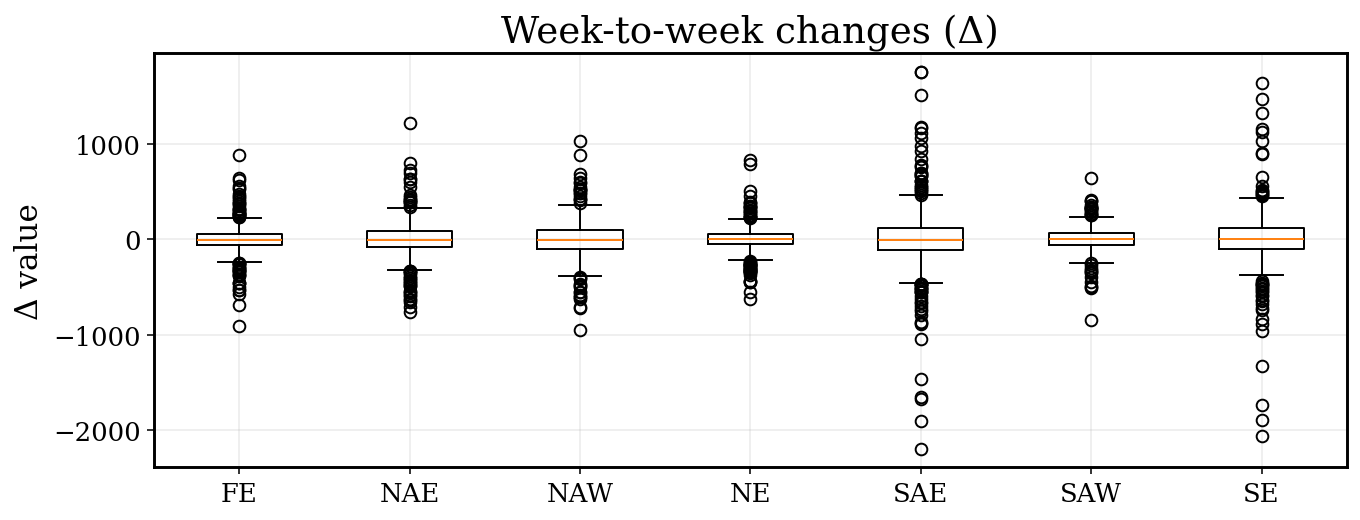

In [8]:
diffs = df[vars_].diff().dropna()
plt.figure(figsize=(10, 4))
plt.boxplot([diffs[v].values for v in vars_], labels=vars_, showfliers=True)
plt.title("Week-to-week changes (Δ)")
plt.ylabel("Δ value")
plt.tight_layout()
plt.show()


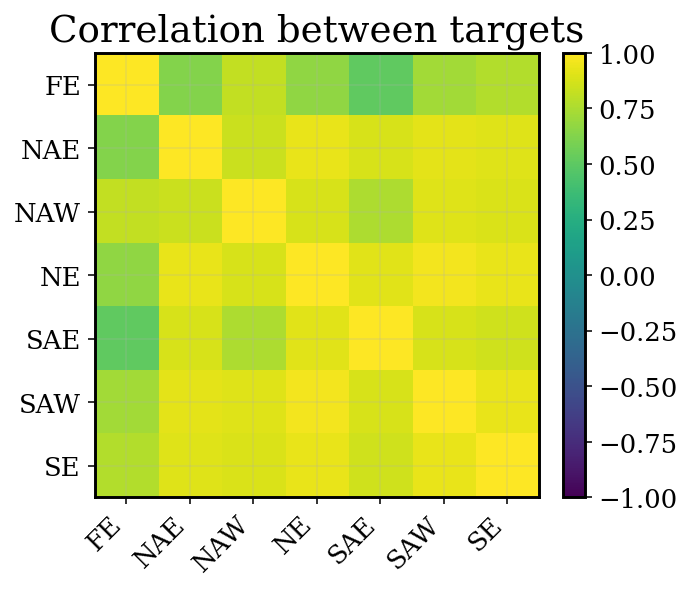

In [9]:
corr = df[vars_].corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr.values, vmin=-1, vmax=1)
ax.set_xticks(range(len(vars_))); ax.set_xticklabels(vars_, rotation=45, ha="right")
ax.set_yticks(range(len(vars_))); ax.set_yticklabels(vars_)
ax.set_title("Correlation between targets")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


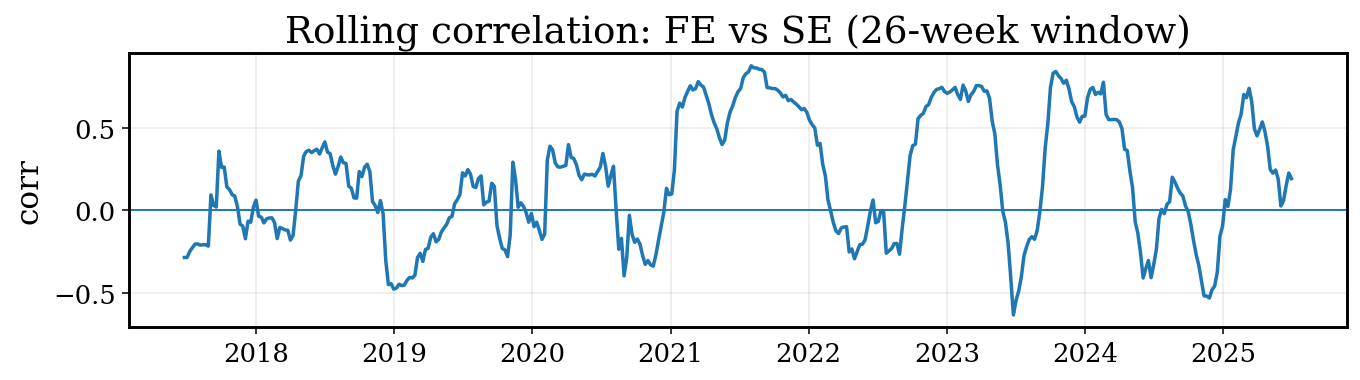

In [10]:
a, b = "FE", "SE"
roll = df[[a, b]].rolling(26).corr().unstack().iloc[:,1]  # 26w rolling corr

plt.figure(figsize=(10, 3))
plt.plot(roll.index, roll.values, linewidth=1.8)
plt.title(f"Rolling correlation: {a} vs {b} (26-week window)")
plt.ylabel("corr")
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()


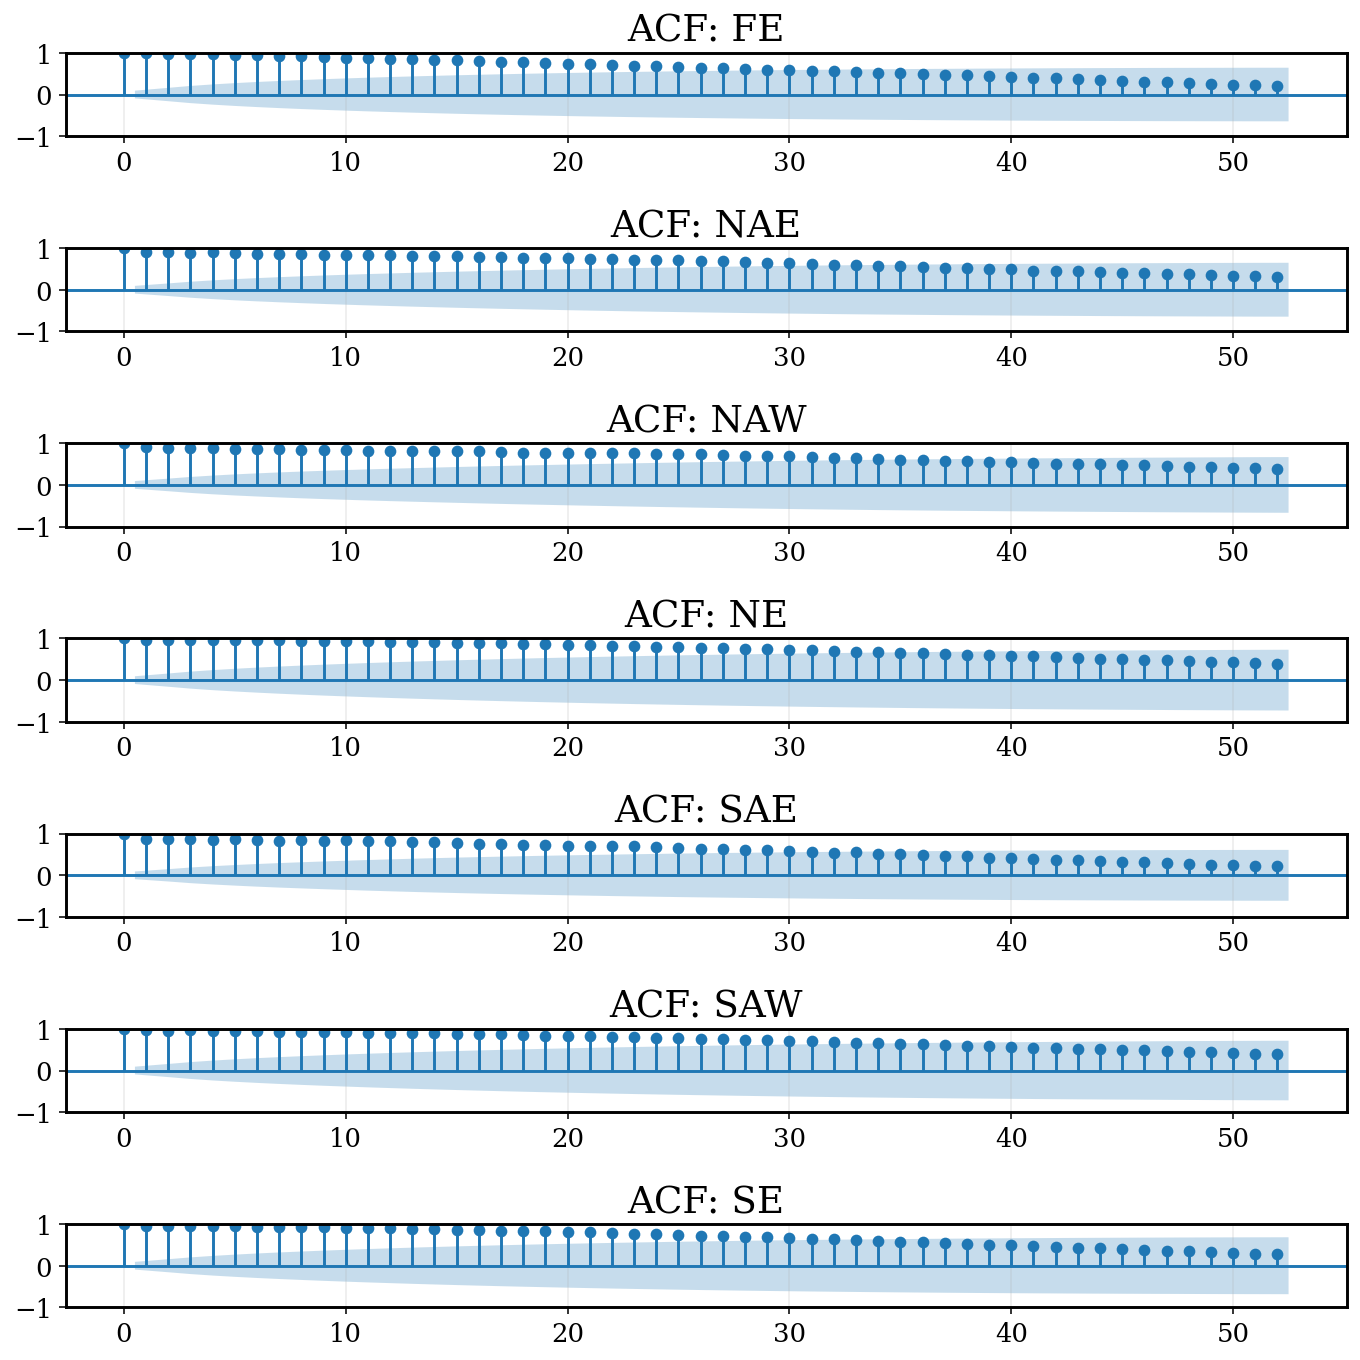

In [11]:
from statsmodels.graphics.tsaplots import plot_acf

lags = 52  # one year of weekly lags
fig, axes = plt.subplots(len(vars_), 1, figsize=(10, 10))

for ax, v in zip(axes, vars_):
    plot_acf(df[v].dropna(), lags=lags, ax=ax, title=f"ACF: {v}")

plt.tight_layout()
plt.show()
